In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import host_utils as utils
from astropy.cosmology import Planck15
from astropy import units as u

In [2]:
import arepo_package as arepo

In [3]:
import scienceplots
plt.style.use(['science'])
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [4]:

pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0',
    brahma_simName_array[5]: '#02818a'
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[0,0,10,1])
    brahma_control = control.control_sample_brahma(brahma_pop_Nstar10)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.2,min_N_values=10)
    


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = brahma_sim_zbins
#sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


processing each merger redshifts for controls: 100%|██████████| 83/83 [00:06<00:00, 12.15it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:362: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 14
SM5_TNG


finding controls: 100%|██████████| 796/796 [00:00<00:00, 22065.95it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:632: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:636: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:639: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 173
number of processable mergers with valid controls:
603
[22, 20, 37, 53, 89, 88, 112, 87, 42, 31, 15]
SM5_LW10_TNG


...

Number of cases where a close enough match is not found within the acceptable tolerance: 424
number of processable mergers with valid controls:
695
[38, 40, 47, 86, 103, 86, 115, 84, 59, 20, 12]
SM5_LW10_LOWSPIN_TNG


finding controls: 100%|██████████| 494/494 [00:00<00:00, 23423.65it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 119
number of processable mergers with valid controls:
366
[21, 17, 13, 30, 40, 35, 68, 51, 35, 25, 19, 10]
SM5_LW10_LOWSPIN_RICH_TNG


finding controls: 100%|██████████| 177/177 [00:00<00:00, 21999.40it/s]

Number of cases where a close enough match is not found within the acceptable tolerance: 46
number of processable mergers with valid controls:
130
[10, 15, 16, 13, 19, 13, 17, 12, 13]
[55, 57, 54, 63, 65, 57, 70, 50]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 3.8]
Brahma common zbins: [0.  0.2 0.8 1.4 2.  2.6 3.2 4.1 5.  8.1]


In [5]:
t_delays = utils.find_merger_time_delays(sim_objs,sim_names)

## Enhancement with massive BH or luminous BH

#### Difference between most massive BH's accretion and total accretion

Text(0.5, 1.0, 'SM5_LW10_DFD_3_TNG')

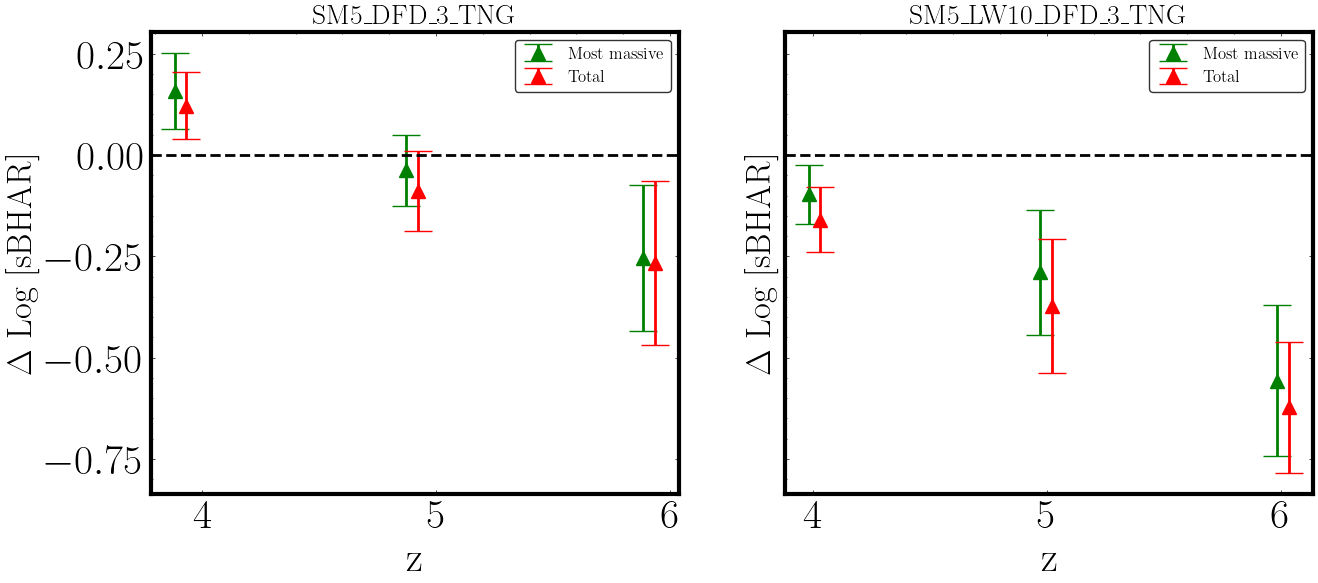

In [6]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=20,labelsize=25,xlabelsize=30,ylabelsize=30,legendsize=15,bold=True)

fig, axes = plt.subplots(1,2, figsize=(15,6),sharey=True)

z_offset_left = 0.05
i=0


unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td('SM5_DFD_3_TNG',sim_objs,t_delays,min_count=10,td_threshold=0.6,type='massive')
axes[0].errorbar(
    unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
    fmt='^', capsize=10, markersize=10, 
    label='Most massive', color='green', alpha=1, linewidth=2
)
i += 1

unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td('SM5_DFD_3_TNG',sim_objs,t_delays,min_count=10,td_threshold=0.6,type='total')
axes[0].errorbar(
    unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
    fmt='^', capsize=10, markersize=10, 
    label='Total', color='r', alpha=1, linewidth=2
)
i += 1
    
axes[0].axhline(0, ls='--', color='black', linewidth=2)
axes[0].set_ylabel('$\Delta$ Log [sBHAR]')
axes[0].set_xlabel('z',fontsize=30)
axes[0].legend(frameon=True, edgecolor='black', fontsize=12)
axes[0].set_title('SM5_DFD_3_TNG')

unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td('SM5_LW10_DFD_3_TNG',sim_objs,t_delays,min_count=10,td_threshold=0.6,type='massive')
axes[1].errorbar(
    unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
    fmt='^', capsize=10, markersize=10, 
    label='Most massive', color='green', alpha=1, linewidth=2
)
i += 1

unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td('SM5_LW10_DFD_3_TNG',sim_objs,t_delays,min_count=10,td_threshold=0.6,type='total')
axes[1].errorbar(
    unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
    fmt='^', capsize=10, markersize=10, 
    label='Total', color='r', alpha=1, linewidth=2
)
i += 1
    
axes[1].axhline(0, ls='--', color='black', linewidth=2)
axes[1].set_ylabel('$\Delta$ Log [sBHAR]')
axes[1].set_xlabel('z',fontsize=30)
axes[1].legend(frameon=True, edgecolor='black', fontsize=12)
axes[1].set_title('SM5_LW10_DFD_3_TNG')


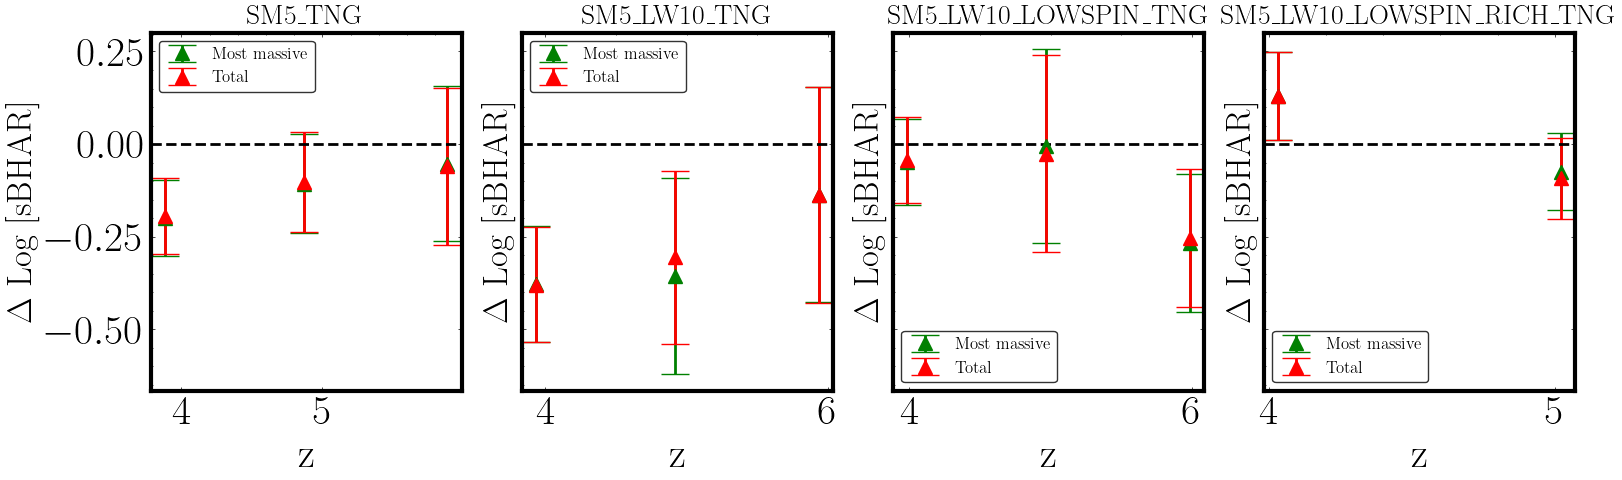

In [7]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=20,labelsize=25,xlabelsize=30,ylabelsize=30,legendsize=15,bold=True)

fig, axes = plt.subplots(1,4, figsize=(16,5),sharey=True)

z_offset_left = 0.05
# i=0

sims_to_plot = ['SM5_TNG','SM5_LW10_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']

for i in range(4):


    unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td(sims_to_plot[i],sim_objs,t_delays,min_count=10,td_threshold=0.6,type='massive')
    axes[i].errorbar(
        unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
        fmt='^', capsize=10, markersize=10, 
        label='Most massive', color='green', alpha=1, linewidth=2
    )

    unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td(sims_to_plot[i],sim_objs,t_delays,min_count=10,td_threshold=0.6,type='total')
    axes[i].errorbar(
        unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
        fmt='^', capsize=10, markersize=10, 
        label='Total', color='r', alpha=1, linewidth=2
    )

    axes[i].axhline(0, ls='--', color='black', linewidth=2)
    axes[i].set_ylabel('$\Delta$ Log [sBHAR]')
    axes[i].set_xlabel('z',fontsize=30)
    axes[i].legend(frameon=True, edgecolor='black', fontsize=12)
    axes[i].set_title(sims_to_plot[i])

fig.tight_layout()

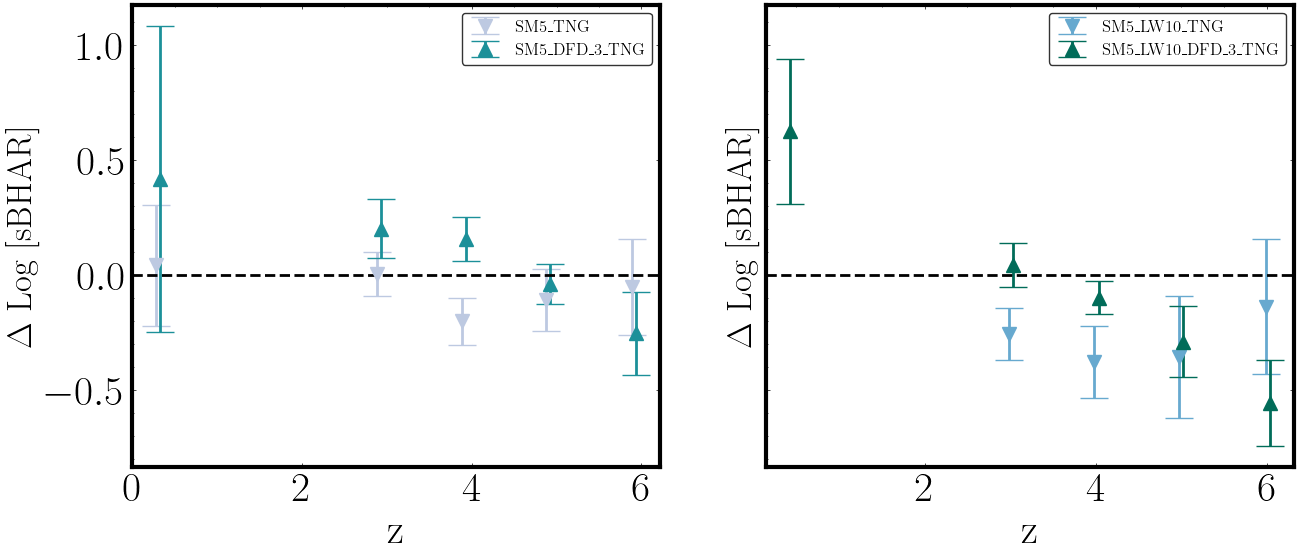

In [8]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=20,labelsize=25,xlabelsize=30,ylabelsize=30,legendsize=15,bold=True)

fig, axes = plt.subplots(1,2, figsize=(15,6),sharey=True)

z_offset_left = 0.05
i=0

sim_name_to_plot = ['SM5_TNG','SM5_DFD_3_TNG']
for sim in sim_name_to_plot:
    if 'DFD' in sim:
        marker = '^'
    else:
        marker ='v'

    unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td(sim,sim_objs,t_delays,min_count=10,td_threshold=0.9,type='massive')
    axes[0].errorbar(
        unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2
    )
    i += 1
    

sim_name_to_plot = ['SM5_LW10_TNG','SM5_LW10_DFD_3_TNG']
for sim in sim_name_to_plot:
    if 'DFD' in sim:
        marker = '^'
    else:
        marker ='v'

    unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td(sim,sim_objs,t_delays,min_count=10,td_threshold=0.9,type='massive')
    axes[1].errorbar(
        unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2
    )
    i += 1

axes[0].axhline(0, ls='--', color='black', linewidth=2)
axes[0].set_ylabel('$\Delta$ Log [sBHAR]')
axes[0].set_xlabel('z',fontsize=30)
axes[0].legend(frameon=True, edgecolor='black', fontsize=12)


axes[1].axhline(0, ls='--', color='black', linewidth=2)
axes[1].set_ylabel('$\Delta$ Log [sBHAR]')
axes[1].set_xlabel('z',fontsize=30)
axes[1].legend(frameon=True, edgecolor='black', fontsize=12)
# axes.set_title('Enhancements in MBH merger hosts')
# axes.legend(frameon=True, edgecolor='black')





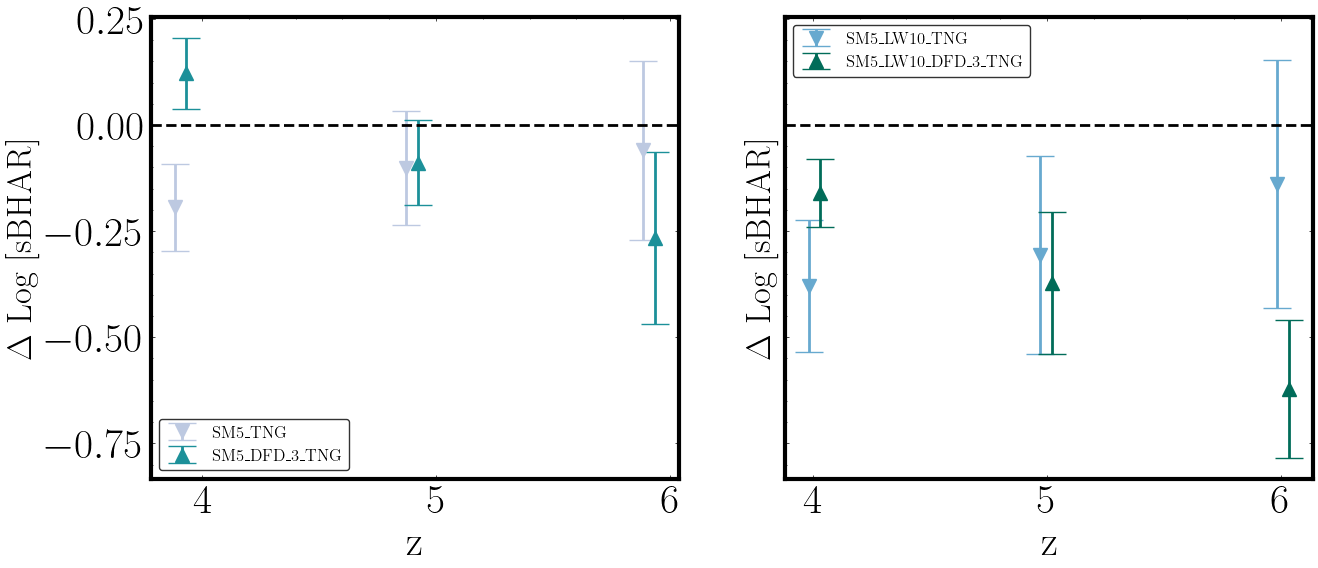

In [9]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=20,labelsize=25,xlabelsize=30,ylabelsize=30,legendsize=15,bold=True)

fig, axes = plt.subplots(1,2, figsize=(15,6),sharey=True)

z_offset_left = 0.05
i=0

sim_name_to_plot = ['SM5_TNG','SM5_DFD_3_TNG']
for sim in sim_name_to_plot:
    if 'DFD' in sim:
        marker = '^'
    else:
        marker ='v'

    unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td(sim,sim_objs,t_delays,min_count=10,td_threshold=0.6,type='total')
    axes[0].errorbar(
        unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2
    )
    i += 1
    

sim_name_to_plot = ['SM5_LW10_TNG','SM5_LW10_DFD_3_TNG']
for sim in sim_name_to_plot:
    if 'DFD' in sim:
        marker = '^'
    else:
        marker ='v'

    unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td(sim,sim_objs,t_delays,min_count=10,td_threshold=0.6,type='total')
    axes[1].errorbar(
        unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2
    )
    i += 1

axes[0].axhline(0, ls='--', color='black', linewidth=2)
axes[0].set_ylabel('$\Delta$ Log [sBHAR]')
axes[0].set_xlabel('z',fontsize=30)
axes[0].legend(frameon=True, edgecolor='black', fontsize=12)


axes[1].axhline(0, ls='--', color='black', linewidth=2)
axes[1].set_ylabel('$\Delta$ Log [sBHAR]')
axes[1].set_xlabel('z',fontsize=30)
axes[1].legend(frameon=True, edgecolor='black', fontsize=12)
# axes.set_title('Enhancements in MBH merger hosts')
# axes.legend(frameon=True, edgecolor='black')


In [10]:
def sBHAR_enhancement_for_massive_and_luminous_BH(sim_obj,zbins,log=True,type='massive'):
    

    avg_sBHAR_enhancement = []
    std_sBHAR_enhancement = []


    for i in range(len(zbins)-1):
        merger_z_mask = (sim_obj.z_merging_pop >= zbins[i]) & (sim_obj.z_merging_pop < zbins[i+1])
        merging_sBHAR_massive = sim_obj.sBHAR_merging_massive_pop[merger_z_mask]
        merging_sBHAR_luminous = sim_obj.sBHAR_merging_luminous_pop[merger_z_mask]
        control_sBHAR_massive = sim_obj.sBHAR_control_massive_pop[merger_z_mask]
        control_sBHAR_luminous = sim_obj.sBHAR_control_luminous_pop[merger_z_mask]

        if log:
            quantity_log_enhancement = []
            for j in range(len(merging_sBHAR_massive)):
                if control_sBHAR_massive[j] > 0 and merging_sBHAR_massive[j] > 0:
                    if type == 'massive':
                        quantity_log_enhancement.append(np.log10(merging_sBHAR_massive[j]/control_sBHAR_massive[j]))
                    else:
                        quantity_log_enhancement.append(np.log10(merging_sBHAR_luminous[j]/control_sBHAR_luminous[j]))

            avg_sBHAR_enhancement.append(np.mean(quantity_log_enhancement))
            std_sBHAR_enhancement.append(np.std(quantity_log_enhancement)/np.sqrt(len(quantity_log_enhancement)))
        else:
            quantity_enhancement = []
            for j in range(len(merging_sBHAR_massive)):
                if control_sBHAR_massive[j] > 0 and merging_sBHAR_massive[j] > 0:
                    if type == 'massive':
                        quantity_enhancement.append(merging_sBHAR_massive[j]/control_sBHAR_massive[j])
                    else:
                        quantity_enhancement.append(merging_sBHAR_luminous[j]/control_sBHAR_luminous[j])
            avg_sBHAR_enhancement.append(np.mean(quantity_enhancement))
    
    avg_sBHAR_enhancement = np.array(avg_sBHAR_enhancement)
    std_sBHAR_enhancement = np.array(std_sBHAR_enhancement)

    return avg_sBHAR_enhancement, std_sBHAR_enhancement

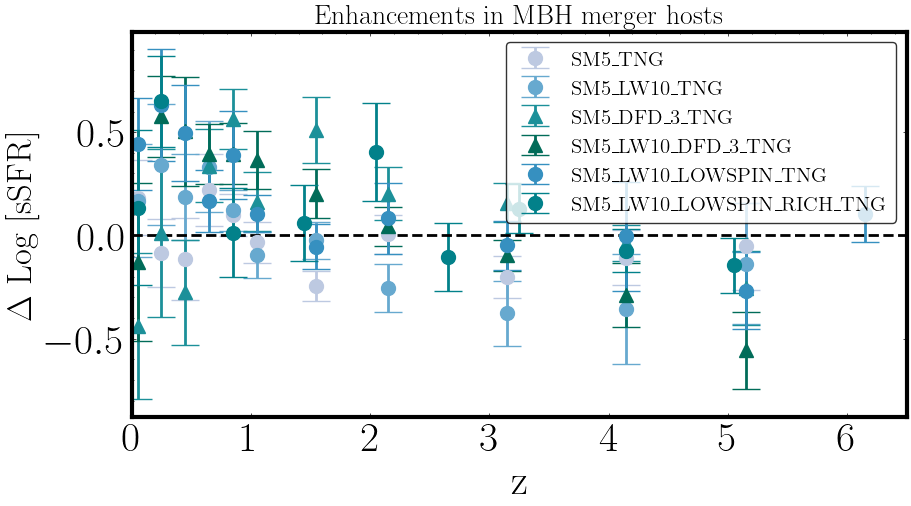

In [11]:
fig, axes = plt.subplots(1,1, figsize=(10,5))

z_offset_left = 0.05
i=0
brahma_plot_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG']

for sim in brahma_simName_array:
    if 'DFD' in sim:
        marker = '^'
    else:
        marker ='o'
    
    avg_sBHAR,std_sBHAR = sBHAR_enhancement_for_massive_and_luminous_BH(sim_objs[sim],sim_zbins_list[sim])
    
    axes.errorbar(sim_zbins_list[sim][:-1]+z_offset_left, avg_sBHAR, yerr=std_sBHAR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2)
    i += 1
    

axes.set_xticks([0, 1, 2, 3, 4, 5, 6])
axes.set_xlim(0,6.5)
#axes.set_ylim(-0.5,0.5)
axes.axhline(0, ls='--', color='black', linewidth=2)
axes.set_ylabel('$\Delta$ Log [sSFR]')
axes.set_xlabel('z',fontsize=30)
axes.set_title('Enhancements in MBH merger hosts')
axes.legend(frameon=True, edgecolor='black')



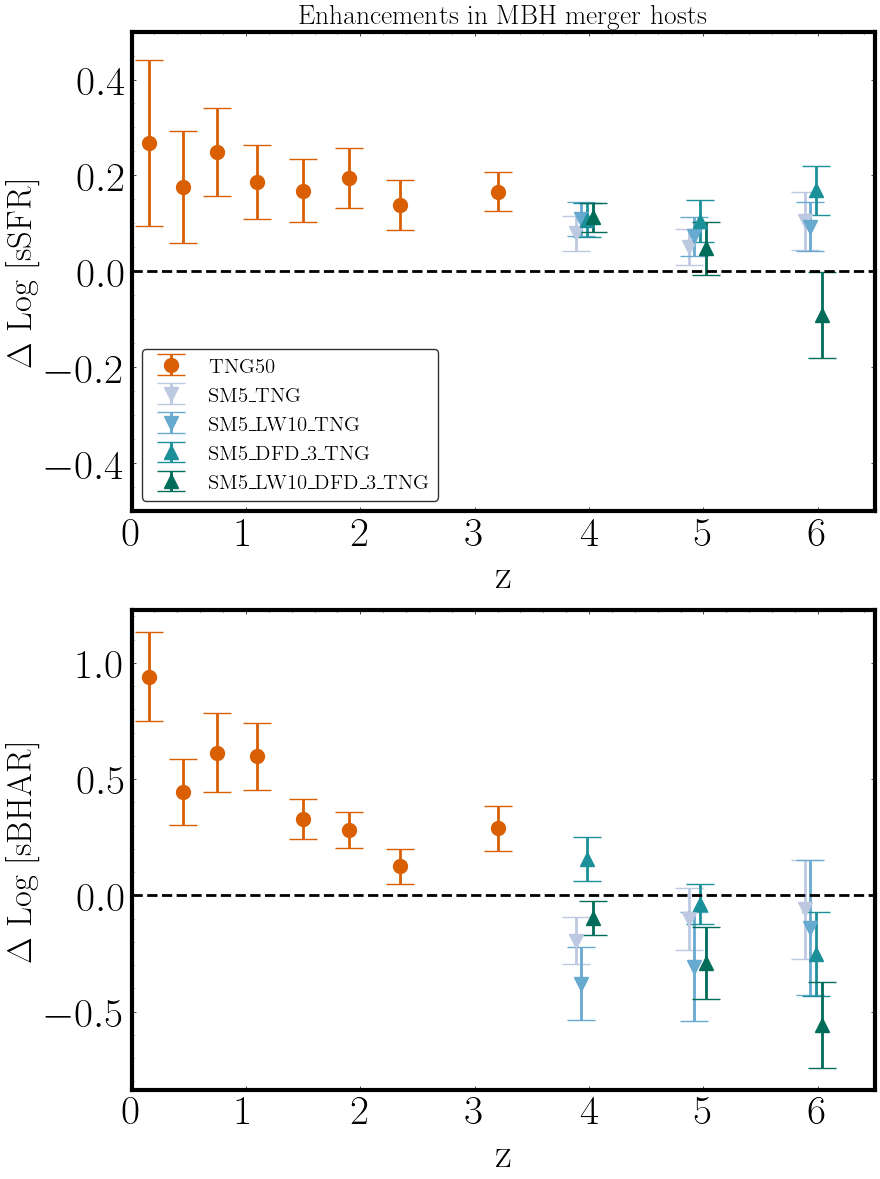

In [15]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=20,labelsize=25,xlabelsize=30,ylabelsize=30,legendsize=15,bold=True)

# Create figure with 1x2 subplots
fig, axes = plt.subplots(2,1, figsize=(9,12))

z_offset_left = 0.05
i = 0
# Plot TNG50
avg_sSFR, std_sSFR = utils.merger_enhancement_calc(sim_objs['TNG50'], 'sSFR', sim_zbins_list['TNG50'], log=True)
z_mid = sim_zbins_list['TNG50'][:-1] + np.diff(sim_zbins_list['TNG50']) / 2

axes[0].errorbar(z_mid, avg_sSFR, yerr=std_sSFR, fmt='o', capsize=10, markersize=10, 
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)

brahma_plot_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG']
#plot BRAHMA sims
for sim in brahma_plot_array:
    marker = '^' if 'DFD' in sim else 'v'  # Use square for DFD, circle otherwise
    unique_z, avg_sSFR, std_sSFR = utils.merger_enhancement_calc_for_small_td(
        sim, sim_objs, t_delays, min_count=10,td_threshold=0.5, quantity='sSFR'
    )
    axes[0].errorbar(
        unique_z + (i - 2.5) * z_offset_left, avg_sSFR, yerr=std_sSFR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2
    )
    i += 1

axes[0].set_xticks([0, 1, 2, 3, 4, 5, 6])
axes[0].set_xlim(0,6.5)
axes[0].set_ylim(-0.5,0.5)
axes[0].axhline(0, ls='--', color='black', linewidth=2)
axes[0].set_ylabel('$\Delta$ Log [sSFR]')
axes[0].set_xlabel('z',fontsize=30)
axes[0].set_title('Enhancements in MBH merger hosts')
axes[0].legend(frameon=True, edgecolor='black')


z_offset_left = 0.05
i = 0
# Plot TNG50
avg_sBHAR, std_sBHAR = utils.merger_enhancement_calc(sim_objs['TNG50'], 'sBHAR', sim_zbins_list['TNG50'], log=True)
z_mid = sim_zbins_list['TNG50'][:-1] + np.diff(sim_zbins_list['TNG50']) / 2

axes[1].errorbar(z_mid, avg_sBHAR, yerr=std_sBHAR, fmt='o', capsize=10, markersize=10, 
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)

i=0
#plot BRAHMA sims
brahma_plot_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG']
for sim in brahma_plot_array:
    marker = '^' if 'DFD' in sim else 'v'  # Use square for DFD, circle otherwise

    if 'DFD' in sim:
        unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td(sim,sim_objs,t_delays,min_count=10,td_threshold=0.6,type='massive')
        axes[1].errorbar(
            unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
            fmt='^', capsize=10, markersize=10, 
            label=sim, color=sim_colors[sim], alpha=1, linewidth=2
        )

    else:
        unique_z, avg_sBHAR, std_sBHAR = utils.merger_enhancement_calc_for_small_td(
            sim, sim_objs, t_delays, min_count=10,td_threshold=0.5, quantity='sBHAR'
        )
        axes[1].errorbar(
            unique_z + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
            fmt=marker, capsize=10, markersize=10, 
            label=sim, color=sim_colors[sim], alpha=1, linewidth=2
        )   
    i += 1

axes[1].axhline(0, ls='--', color='black', linewidth=2)
axes[1].set_ylabel('$\Delta$ Log [sBHAR]')
axes[1].set_xlabel('z',fontsize=30)
axes[1].set_xticks([0, 1, 2, 3, 4, 5, 6])
axes[1].set_xlim(0,6.5)
#axes[1].set_title('TNG50 + BRAHMA ($t_{\mathrm delay} < 0.5$ Gyr)')
# axes[1].legend(frameon=True, edgecolor='black')
# fig.suptitle('Merger enhancements in TNG50 and BRAHMA MBH merger hosts')
fig.tight_layout()
fig.savefig("../../figures/sSFR_and_sBHAR_enhancements_w_z.pdf")

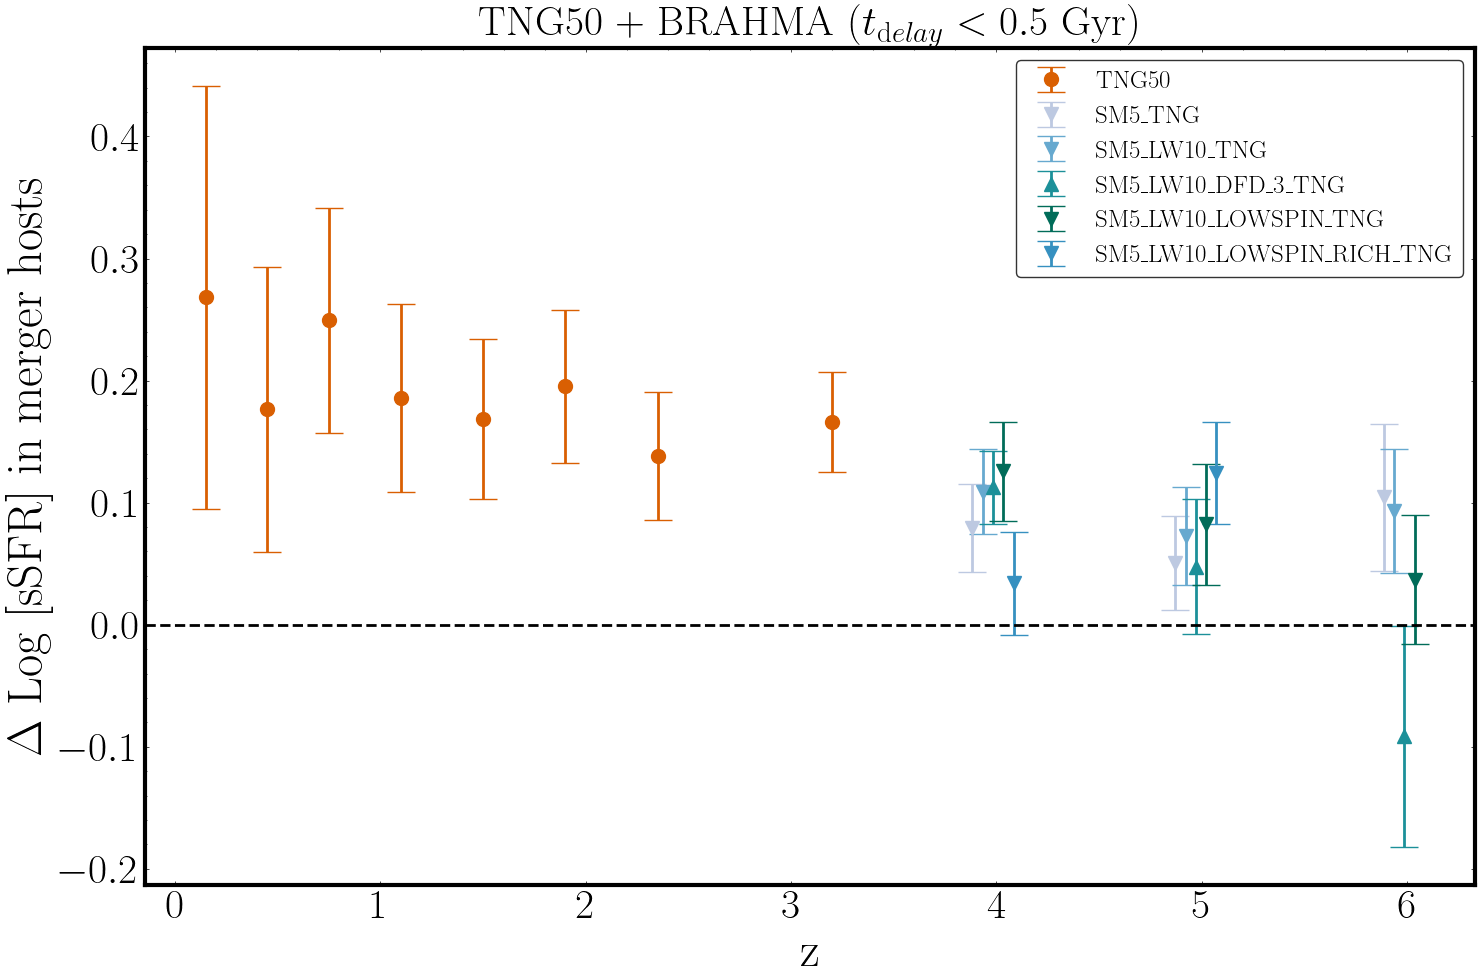

In [7]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=18,bold=True)

# Create figure with 1x2 subplots
fig, ax = plt.subplots(1, 1, figsize=(15,10),sharey=True)

z_offset_left = 0.05
i = 0
# Plot TNG50
avg_sSFR, std_sSFR = utils.merger_enhancement_calc(sim_objs['TNG50'], 'sSFR', sim_zbins_list['TNG50'], log=True)
z_mid = sim_zbins_list['TNG50'][:-1] + np.diff(sim_zbins_list['TNG50']) / 2

ax.errorbar(z_mid, avg_sSFR, yerr=std_sSFR, fmt='o', capsize=10, markersize=10, 
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)

#plot BRAHMA sims
for sim in brahma_simName_array:
    marker = '^' if 'DFD' in sim else 'v'  # Use square for DFD, circle otherwise
    unique_z, avg_sSFR, std_sSFR = utils.merger_enhancement_calc_for_small_td(
        sim, sim_objs, t_delays, min_count=10,td_threshold=0.5, quantity='sSFR'
    )
    ax.errorbar(
        unique_z + (i - 2.5) * z_offset_left, avg_sSFR, yerr=std_sSFR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2
    )
    i += 1

ax.axhline(0, ls='--', color='black', linewidth=2)
ax.set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax.set_xlabel('z')
ax.set_title('TNG50 + BRAHMA ($t_{\mathrm delay} < 0.5$ Gyr)')
ax.legend(frameon=True, edgecolor='black')

fig.tight_layout()
fig.savefig("../../figures/sSFR_enhancements_w_z_for_td_less_than_05Gyr.pdf")

## sBHAR enhancements for td < 0.5 Gyr

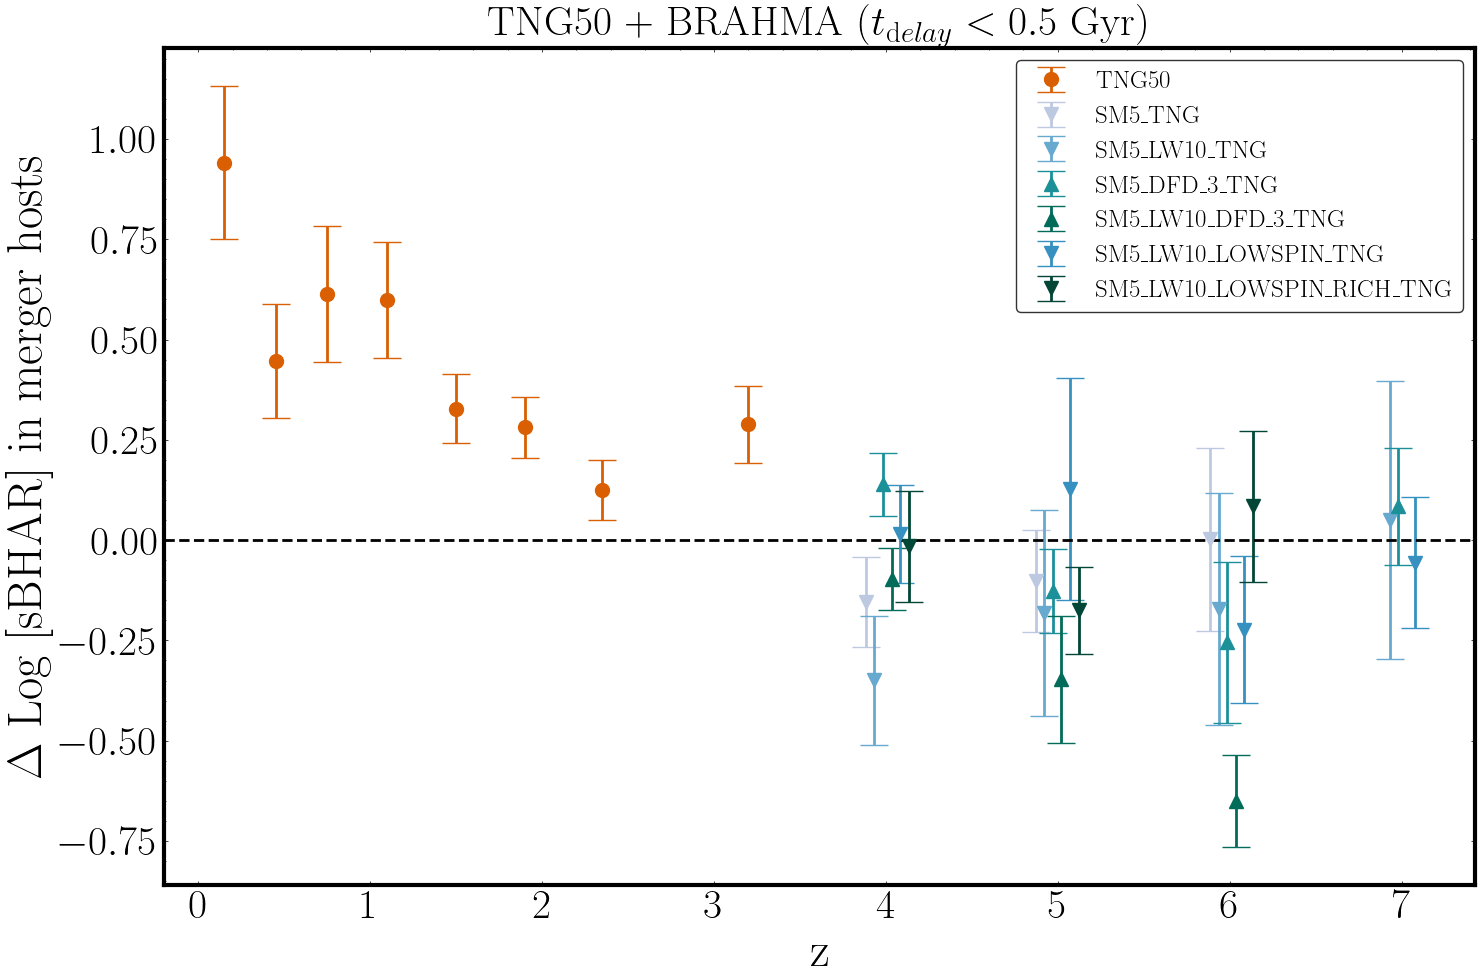

In [8]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=18,bold=True)

# Create figure with 1x2 subplots
fig, ax = plt.subplots(1, 1, figsize=(15,10),sharey=True)

z_offset_left = 0.05
i = 0
# Plot TNG50
avg_sBHAR, std_sBHAR = utils.merger_enhancement_calc(sim_objs['TNG50'], 'sBHAR', sim_zbins_list['TNG50'], log=True)
z_mid = sim_zbins_list['TNG50'][:-1] + np.diff(sim_zbins_list['TNG50']) / 2

ax.errorbar(z_mid, avg_sBHAR, yerr=std_sBHAR, fmt='o', capsize=10, markersize=10, 
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)

i=0
#plot BRAHMA sims
for sim in brahma_simName_array:
    marker = '^' if 'DFD' in sim else 'v'  # Use square for DFD, circle otherwise
    unique_z, avg_sSFR, std_sSFR = utils.merger_enhancement_calc_for_small_td(
        sim, sim_objs, t_delays, min_count=5,td_threshold=0.5, quantity='sBHAR'
    )
    ax.errorbar(
        unique_z + (i - 2.5) * z_offset_left, avg_sSFR, yerr=std_sSFR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2
    )
    i += 1

ax.axhline(0, ls='--', color='black', linewidth=2)
ax.set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax.set_xlabel('z')
ax.set_title('TNG50 + BRAHMA ($t_{\mathrm delay} < 0.5$ Gyr)')
ax.legend(frameon=True, edgecolor='black')
#ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../../figures/sBHAR_enhancements_w_z_for_td_less_than_05Gyr.pdf")

## sSFR vs stellar mass + sBHAR vs BH mass at low-z

/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/utils.py:314: RuntimeWarning: divide by zero encountered in divide
  quantity_enhancement = merging_pop_quantity / control_pop_quantity


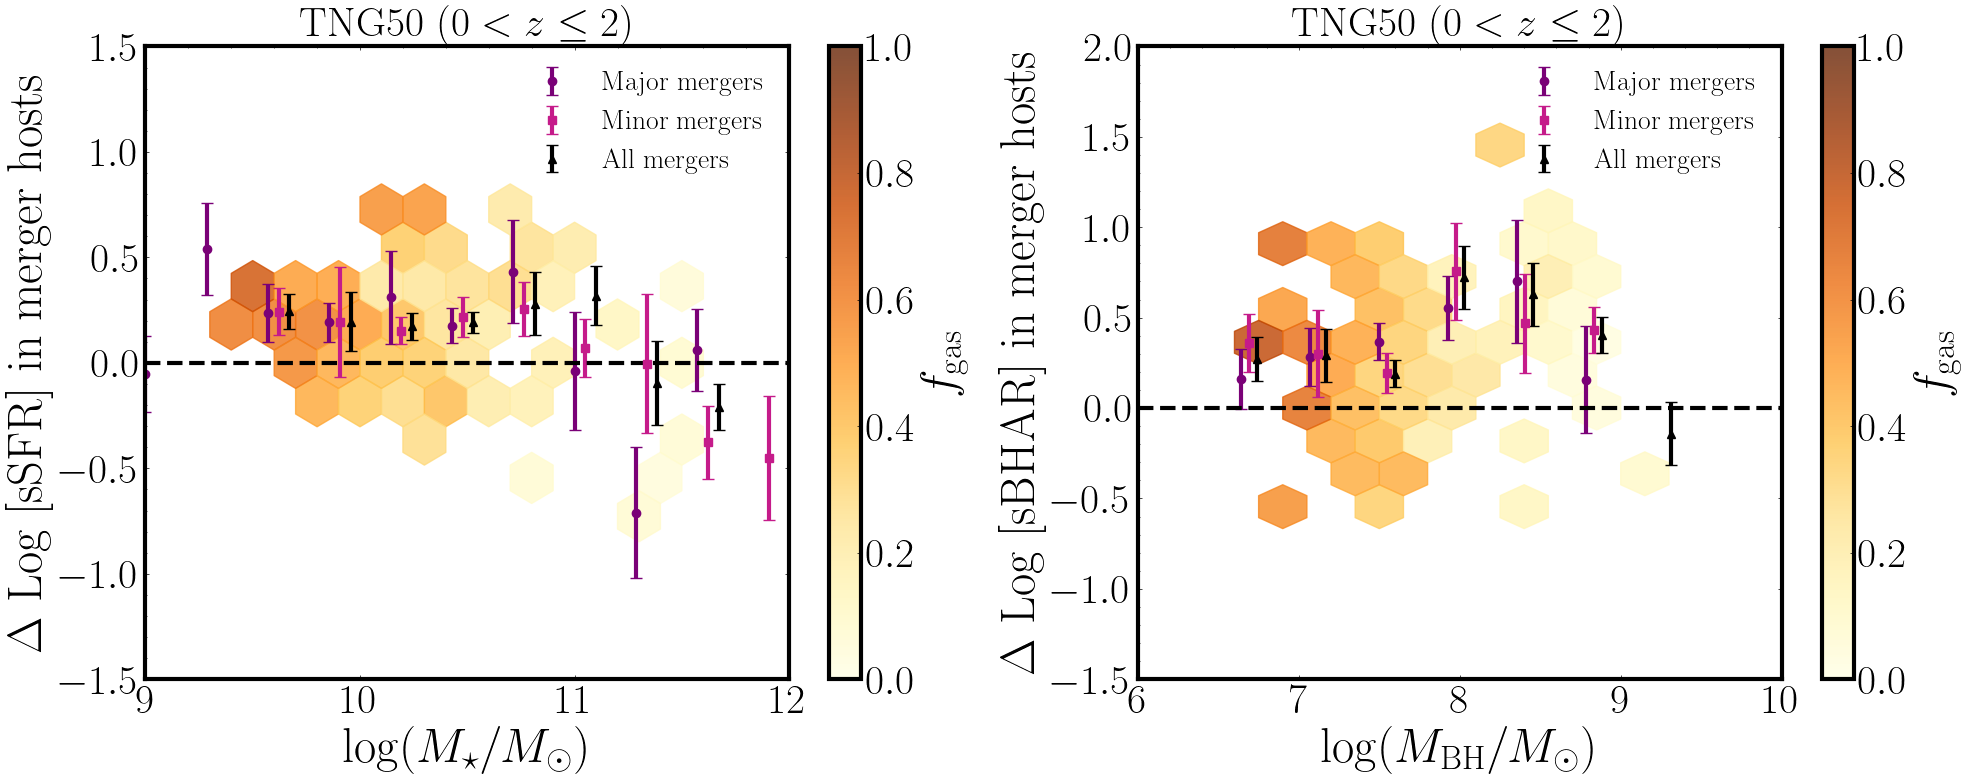

In [9]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=20,bold=True)

fig,ax = plt.subplots(1,2,figsize=(20,8))

log_Mstar_bins = np.linspace(8,12,15)

sim='TNG50'
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=10)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[0] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[0], sim_objs[sim], quantity='sSFR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=8, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[0].set_xlim(9,12)
ax[0].set_ylim(-1.5,1.5)
ax[0].legend()
ax[0].set_title(f'{sim} ($0<z\leq2)$')

log_MBH_bins = np.linspace(6,12,15)

avg_sBHAR_major,std_sBHAR_major = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[1] = utils.make_hex_plot_quantity_vs_black_hole_mass(
    ax[1], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(6,10)
ax[1].set_ylim(-1.5,2)
ax[1].legend()
ax[1].set_title(f'{sim} ($0<z\leq2)$')

fig.tight_layout()
fig.savefig("../../figures/sSFR_and_sBHAR_enhancements_vs_Mstar_and_MBH_TNG50.pdf")

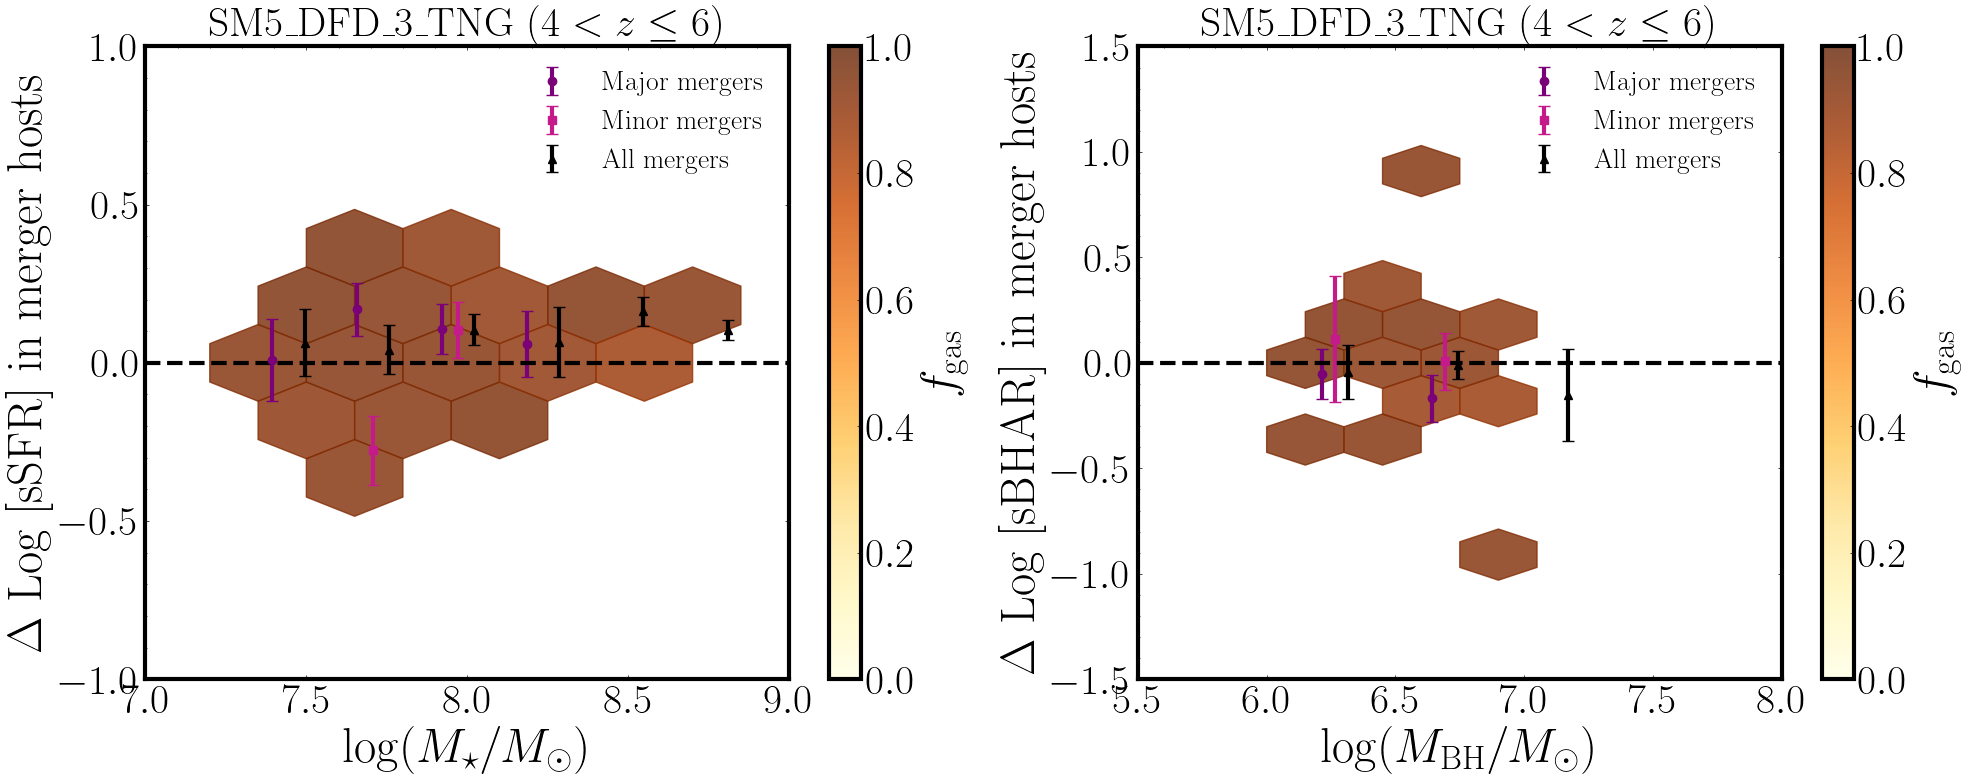

In [10]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=20,bold=True)

fig,ax = plt.subplots(1,2,figsize=(20,8))

log_Mstar_bins = np.linspace(7,12,20)

sim='SM5_DFD_3_TNG'
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=4,zupper=6,log=True,major_merger_flag=True,min_N=4)
avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=4,zupper=6,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=4,zupper=6,log=True,min_N=10)
#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[0] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[0], sim_objs[sim], quantity='sSFR', zlow=4, zupper=6,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[0].set_xlim(7,9)
ax[0].set_ylim(-1,1)
ax[0].legend()
ax[0].set_title(f'{sim} ($4<z\leq6)$')

log_MBH_bins = np.linspace(6,12,15)

avg_sBHAR_major,std_sBHAR_major = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=4,zupper=6,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=4,zupper=6,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=4,zupper=6,log=True,min_N=10)

ax[1] = utils.make_hex_plot_quantity_vs_black_hole_mass(
    ax[1], sim_objs[sim], quantity='sBHAR', zlow=4, zupper=6,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(5.5,8)
ax[1].set_ylim(-1.5,1.5)
ax[1].legend()
ax[1].set_title(f'{sim} ($4<z\leq6)$')

fig.tight_layout()
fig.savefig("../../figures/sSFR_and_sBHAR_enhancements_vs_Mstar_and_MBH_BRAHMA_highz.pdf")

# fgas distribution

In [11]:
TNG_zs,counts_TNG_zs = np.unique(sim_objs['TNG50'].z_merging_pop,return_counts=True)
filtered_TNG_zs = TNG_zs[counts_TNG_zs>=10]
print(filtered_TNG_zs,counts_TNG_zs[counts_TNG_zs>=10])

[0.64464184 1.20625808 1.24847261 1.41409822 1.66666956 1.74357057
 1.82268925 1.90408954 2.00202814 2.10326965 2.20792547 2.31611074
 2.4442257  2.57729027 3.00813107 3.49086137] [11 10 10 18 11 11 11 18 17 13 10 14 11 22 21 11]


In [12]:
SM5_zs,counts_SM5_zs = np.unique(sim_objs['SM5_DFD_3_TNG'].z_merging_pop,return_counts=True)
filtered_TNG_zs = SM5_zs[counts_SM5_zs>=10]
print(filtered_TNG_zs,counts_SM5_zs[counts_SM5_zs>=10])

[2.22044605e-16 9.94018026e-02 1.97284182e-01 2.97717685e-01
 3.99926965e-01 5.03047523e-01 7.00106354e-01 9.97294226e-01
 1.49551217e+00 2.00202814e+00 3.00813107e+00 4.00794511e+00
 4.99593347e+00 6.01075740e+00] [ 10  14  16  27  17  53 106 132 130 187 108  59  36  11]


In [13]:
def find_fgas_mergers_and_controls(sim_obj, z, z_tol=0.25):
    # Select mergers and controls near redshift z
    merger_mask = np.abs(sim_obj.z_merging_pop - z) < z_tol
    control_mask = np.abs(sim_obj.z_control_pop - z) < z_tol
    fgas_merger = sim_obj.fgas_progs[merger_mask]
    fgas_control = sim_obj.fgas_control[control_mask]
    return fgas_merger, fgas_control

TNG50 z~1 merger: median=0.270, std=0.209, N=89
TNG50 z~1 control: median=0.131, std=0.186, N=89
TNG50 z~2 merger: median=0.456, std=0.236, N=69
TNG50 z~2 control: median=0.237, std=0.208, N=69
TNG50 z~3 merger: median=0.348, std=0.273, N=22
TNG50 z~3 control: median=0.151, std=0.211, N=22
SM5_DFD_3_TNG z~4 merger: median=0.923, std=0.043, N=59
SM5_DFD_3_TNG z~4 control: median=0.786, std=0.151, N=59
SM5_DFD_3_TNG z~5 merger: median=0.946, std=0.029, N=36
SM5_DFD_3_TNG z~5 control: median=0.857, std=0.082, N=36
SM5_DFD_3_TNG z~6 merger: median=0.953, std=0.040, N=11
SM5_DFD_3_TNG z~6 control: median=0.867, std=0.065, N=11


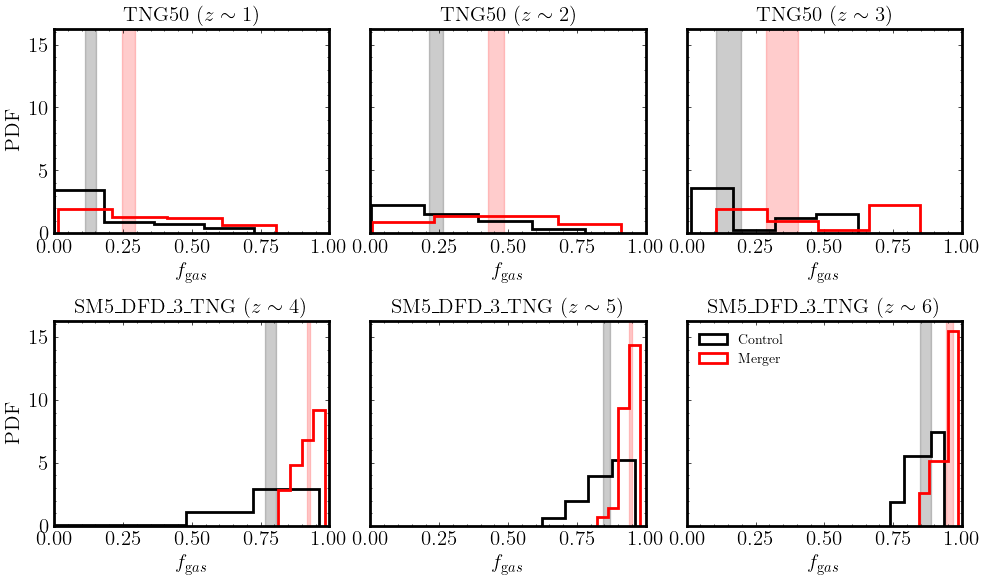

In [14]:
hostplot.set_plot_style(spinewidth=2,linewidth=3, titlesize=15,labelsize=15,xlabelsize=15,ylabelsize=15,legendsize=10,bold=True)
fig, axes = plt.subplots(2,3, figsize=(10,6),sharey=True)

z_TNG = [1,2,3]

#plot TNG f-gas distributions 
for i,z in enumerate(z_TNG):
    ax = axes[0,i]
    fgas_merger,fgas_control = find_fgas_mergers_and_controls(sim_objs['TNG50'], z)
    merger_bins = np.linspace(np.min(fgas_merger),np.max(fgas_merger),5)
    control_bins = np.linspace(np.min(fgas_control),np.max(fgas_control),5)
    ax.hist(fgas_control, bins=control_bins, density=True, label='Control', color='black',histtype='step',linewidth=2)
    ax.hist(fgas_merger, bins=merger_bins, density=True, label='Merger', color='red',histtype='step',linewidth=2)
    
    # Median and standard error for merger
    if len(fgas_merger) > 0:
        median_merger = np.median(fgas_merger)
        stderr_merger = np.std(fgas_merger, ddof=1) / np.sqrt(len(fgas_merger))
        std_merger = np.std(fgas_merger, ddof=1)
        ax.axvspan(median_merger-stderr_merger, median_merger+stderr_merger, color='red', alpha=0.2)
        print(f"TNG50 z~{z} merger: median={median_merger:.3f}, std={std_merger:.3f}, N={len(fgas_merger)}")
    # Median and standard error for control
    if len(fgas_control) > 0:
        median_control = np.median(fgas_control)
        stderr_control = np.std(fgas_control, ddof=1) / np.sqrt(len(fgas_control))
        std_control = np.std(fgas_control, ddof=1)
        ax.axvspan(median_control-stderr_control, median_control+stderr_control, color='black', alpha=0.2)
        print(f"TNG50 z~{z} control: median={median_control:.3f}, std={std_control:.3f}, N={len(fgas_control)}")

    
    ax.set_title(f'TNG50 ($z\sim{z})$')
    ax.set_xlabel('$f_{\mathrm gas}$')
    ax.set_xlim(0,1)
    if i == 0:
        ax.set_ylabel('PDF')
        
#plot BRAHMA f-gas distributions 

z_BRAHMA = [4,5,6]
for i,z in enumerate(z_BRAHMA):
    ax = axes[1,i]
    fgas_merger,fgas_control = find_fgas_mergers_and_controls(sim_objs['SM5_DFD_3_TNG'], z)
    merger_bins = np.linspace(np.min(fgas_merger),np.max(fgas_merger),5)
    control_bins = np.linspace(np.min(fgas_control),np.max(fgas_control),5)
    ax.hist(fgas_control, bins=control_bins, density=True, label='Control', color='black',histtype='step',linewidth=2)
    ax.hist(fgas_merger, bins=merger_bins, density=True, label='Merger', color='red',histtype='step',linewidth=2)
    
    # Median and standard error for merger
    if len(fgas_merger) > 0:
        median_merger = np.median(fgas_merger)
        stderr_merger = np.std(fgas_merger, ddof=1) / np.sqrt(len(fgas_merger))
        std_merger = np.std(fgas_merger, ddof=1)
        ax.axvspan(median_merger-stderr_merger, median_merger+stderr_merger, color='red', alpha=0.2)
        print(f"SM5_DFD_3_TNG z~{z} merger: median={median_merger:.3f}, std={std_merger:.3f}, N={len(fgas_merger)}")
    # Median and standard error for control
    if len(fgas_control) > 0:
        median_control = np.median(fgas_control)
        stderr_control = np.std(fgas_control, ddof=1) / np.sqrt(len(fgas_control))
        std_control = np.std(fgas_control, ddof=1)
        ax.axvspan(median_control-stderr_control, median_control+stderr_control, color='black', alpha=0.2)
        print(f"SM5_DFD_3_TNG z~{z} control: median={median_control:.3f}, std={std_control:.3f}, N={len(fgas_control)}")

    
    ax.set_title(f'SM5_DFD_3_TNG ($z\sim{z})$')
    ax.set_xlabel('$f_{\mathrm gas}$')
    if i == 0:
        ax.set_ylabel('PDF')
        
    if i==2:
        ax.legend()
    ax.set_xlim(0,1)

fig.tight_layout()
fig.savefig("../../fgas-mergers-and-controls-dist-across-zs.pdf")

In [15]:
h = 0.6774

## sBHAR vs z for BRAHMA

In [16]:
def calculate_quantity_at_z_interval(ax,sim_obj,zbins,quantity='sBHAR'):
    avg_quantity_merger = []
    std_quantity_merger = []

    avg_quantity_control = []
    std_quantity_control = []
    
    for i in range(len(zbins) - 1):
        zini = zbins[i]
        zfinal = zbins[i+1]
        merger_z_mask = (sim_obj.z_merging_pop >= zini) & (sim_obj.z_merging_pop < zfinal)
        
        merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[merger_z_mask]
        control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[merger_z_mask]

        control_non_na_mask = ~np.isnan(control_pop_quantity)

        merging_pop_quantity = merging_pop_quantity[control_non_na_mask]
        control_pop_quantity = control_pop_quantity[control_non_na_mask]

        if quantity=="Mdot":
            merging_pop_quantity = merging_pop_quantity / h**2  # Convert to Msun/yr
            control_pop_quantity = control_pop_quantity / h**2  # Convert to Msun/yr

        if merging_pop_quantity.size > 0:
            avg_quantity_merger.append(np.mean(merging_pop_quantity))
            std_quantity_merger.append(np.std(merging_pop_quantity) / np.sqrt(merging_pop_quantity.size))
    

        if control_pop_quantity.size > 0:
            avg_quantity_control.append(np.mean(control_pop_quantity))
            std_quantity_control.append(np.std(control_pop_quantity) / np.sqrt(control_pop_quantity.size))
        
    
    avg_quantity_merger = np.array(avg_quantity_merger)
    std_quantity_merger = np.array(std_quantity_merger)
    avg_quantity_control = np.array(avg_quantity_control)
    std_quantity_control = np.array(std_quantity_control)
    if ax is None:
        fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    else:
        ax.plot(zbins[:-1], np.log10(avg_quantity_merger[avg_quantity_merger>0]), label='Merger host', color="dodgerblue")
        ax.fill_between(zbins[:-1], np.log10(avg_quantity_merger-std_quantity_merger), np.log10(avg_quantity_merger+std_quantity_merger), alpha=0.3,color='dodgerblue')
        ax.plot(zbins[:-1], np.log10(avg_quantity_control[avg_quantity_control>0]), label='Control', color='orange')
        ax.fill_between(zbins[:-1], np.log10(avg_quantity_control-std_quantity_control), np.log10(avg_quantity_control+std_quantity_control), alpha=0.3,color='orange')
        #ax[0].legend()

    return ax

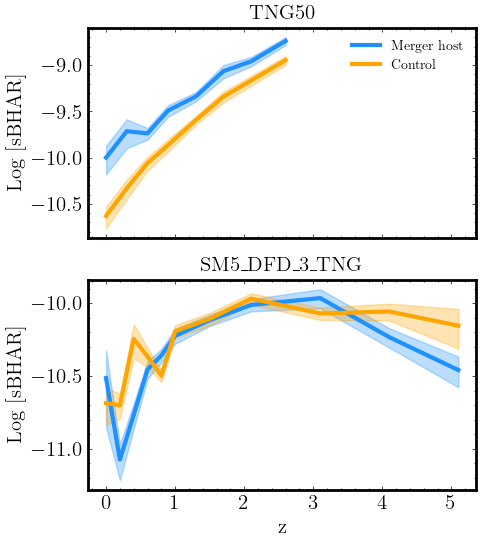

In [17]:
fig, ax = plt.subplots(2,1, figsize=(5, 6), sharex=True)
calculate_quantity_at_z_interval(ax[0], sim_objs['TNG50'], sim_zbins_list['TNG50'], quantity='sBHAR')
calculate_quantity_at_z_interval(ax[1], sim_objs['SM5_DFD_3_TNG'], sim_zbins_list['SM5_DFD_3_TNG'], quantity='sBHAR')
ax[0].set_ylabel('Log [sBHAR]')
ax[0].set_title('TNG50')
ax[1].set_ylabel('Log [sBHAR]')
ax[1].set_title('SM5_DFD_3_TNG')
ax[1].set_xlabel('z')
ax[0].legend()

In [18]:
np.sum(np.isnan(sim_objs['SM5_DFD_3_TNG'].sBHAR_control_pop))

18

Text(0.5, 1.0, 'SM5_LW10_TNG')

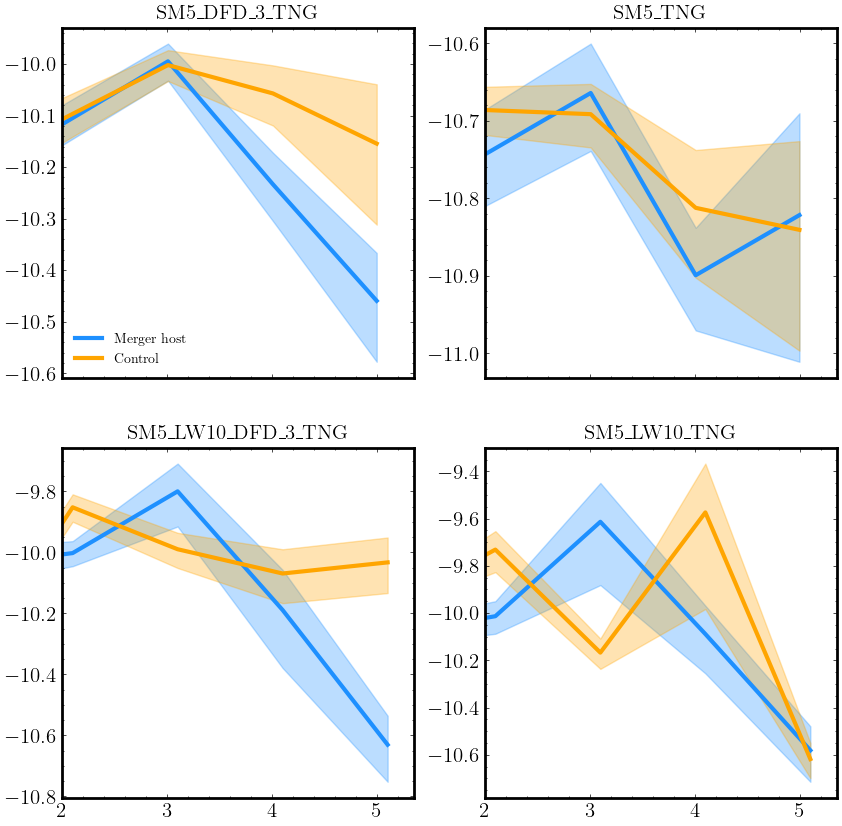

In [19]:
fig, ax = plt.subplots(2,2, figsize=(10, 10), sharex=True)
zbinn = [ 2.002, 3.008, 4.008, 4.996, 6.011]

calculate_quantity_at_z_interval(ax[0,0],sim_objs['SM5_DFD_3_TNG'],zbinn,quantity='sBHAR')
calculate_quantity_at_z_interval(ax[0,1],sim_objs['SM5_TNG'],zbinn,quantity='sBHAR')
calculate_quantity_at_z_interval(ax[1,0],sim_objs['SM5_LW10_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='sBHAR')
calculate_quantity_at_z_interval(ax[1,1],sim_objs['SM5_LW10_TNG'],sim_zbins_list['SM5_TNG'],quantity='sBHAR')
ax[0,0].set_xlim(2,)
ax[0,1].set_xlim(2,)
ax[0,0].legend()
ax[0,0].set_title('SM5_DFD_3_TNG')
ax[0,1].set_title('SM5_TNG')
ax[1,0].set_title('SM5_LW10_DFD_3_TNG')
ax[1,1].set_title('SM5_LW10_TNG')
#calculate_quantitiy_at_z_interval(None,sim_objs['TNG50'],TNG_50_zbins,quantity='sBHAR')

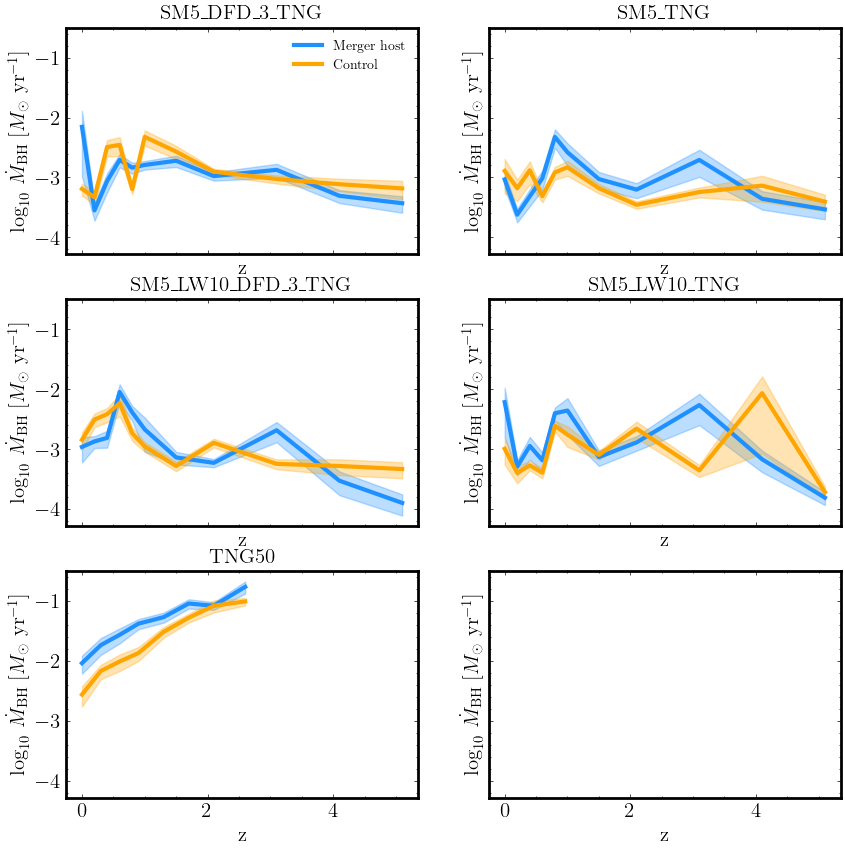

In [20]:
fig, ax = plt.subplots(3,2, figsize=(10, 10), sharex=True,sharey=True)
zbinn = [ 2.002, 3.008, 4.008, 4.996, 6.011]
calculate_quantity_at_z_interval(ax[0,0],sim_objs['SM5_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='Mdot')
calculate_quantity_at_z_interval(ax[0,1],sim_objs['SM5_TNG'],sim_zbins_list['SM5_TNG'],quantity='Mdot')
calculate_quantity_at_z_interval(ax[1,0],sim_objs['SM5_LW10_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='Mdot')
calculate_quantity_at_z_interval(ax[1,1],sim_objs['SM5_LW10_TNG'],sim_zbins_list['SM5_TNG'],quantity='Mdot')
calculate_quantity_at_z_interval(ax[2,0],sim_objs['TNG50'],sim_zbins_list['TNG50'],quantity='Mdot')
# ax[0,0].set_xlim(2,)
# ax[0,1].set_xlim(2,)
ax[0,0].legend()
ax[0,0].set_title('SM5_DFD_3_TNG')
ax[0,1].set_title('SM5_TNG')
ax[1,0].set_title('SM5_LW10_DFD_3_TNG')
ax[1,1].set_title('SM5_LW10_TNG')
ax[2,0].set_title('TNG50')
for i in range(3):
    for j in range(2):
        ax[i,j].set_xlabel('z')
        ax[i,j].set_ylabel(r"$\log_{10}\,\dot{M}_{\rm BH}\;[M_\odot\ \mathrm{yr}^{-1}]$")

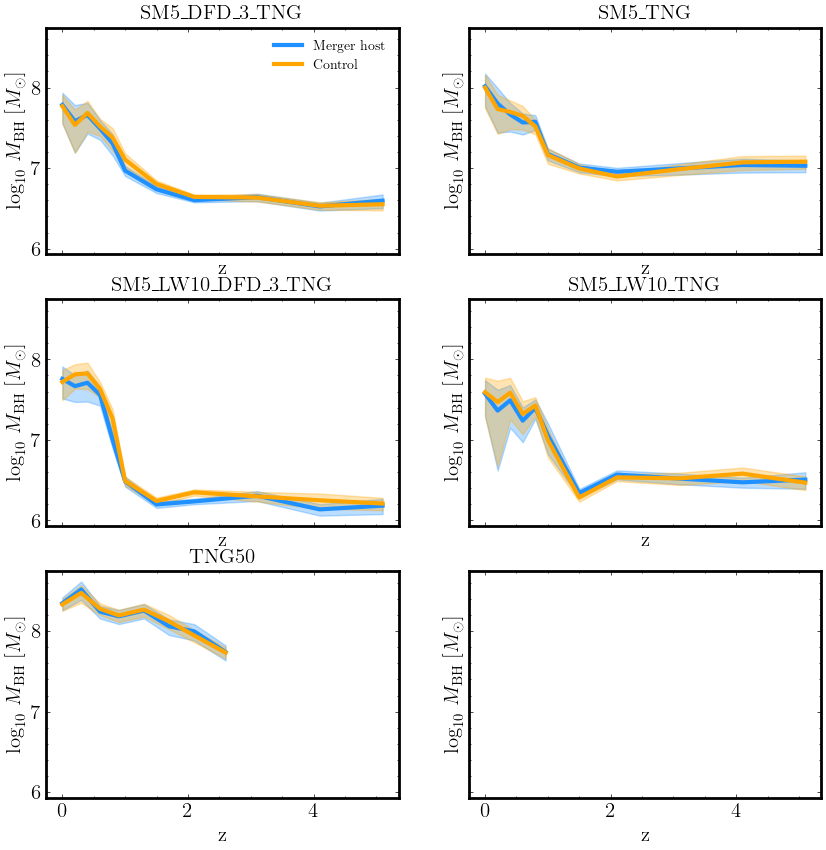

In [21]:
fig, ax = plt.subplots(3,2, figsize=(10, 10), sharex=True,sharey=True)
zbinn = [ 2.002, 3.008, 4.008, 4.996, 6.011]
calculate_quantity_at_z_interval(ax[0,0],sim_objs['SM5_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='MBH')
calculate_quantity_at_z_interval(ax[0,1],sim_objs['SM5_TNG'],sim_zbins_list['SM5_TNG'],quantity='MBH')
calculate_quantity_at_z_interval(ax[1,0],sim_objs['SM5_LW10_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='MBH')
calculate_quantity_at_z_interval(ax[1,1],sim_objs['SM5_LW10_TNG'],sim_zbins_list['SM5_TNG'],quantity='MBH')
calculate_quantity_at_z_interval(ax[2,0],sim_objs['TNG50'],sim_zbins_list['TNG50'],quantity='MBH')
# ax[0,0].set_xlim(2,)
# ax[0,1].set_xlim(2,)
ax[0,0].legend()
ax[0,0].set_title('SM5_DFD_3_TNG')
ax[0,1].set_title('SM5_TNG')
ax[1,0].set_title('SM5_LW10_DFD_3_TNG')
ax[1,1].set_title('SM5_LW10_TNG')
ax[2,0].set_title('TNG50')
for i in range(3):
    for j in range(2):
        ax[i,j].set_xlabel('z')
        ax[i,j].set_ylabel(r"$\log_{10}\,M_{\rm BH}\;[M_\odot]$")

Text(0.5, 1.0, 'TNG50')

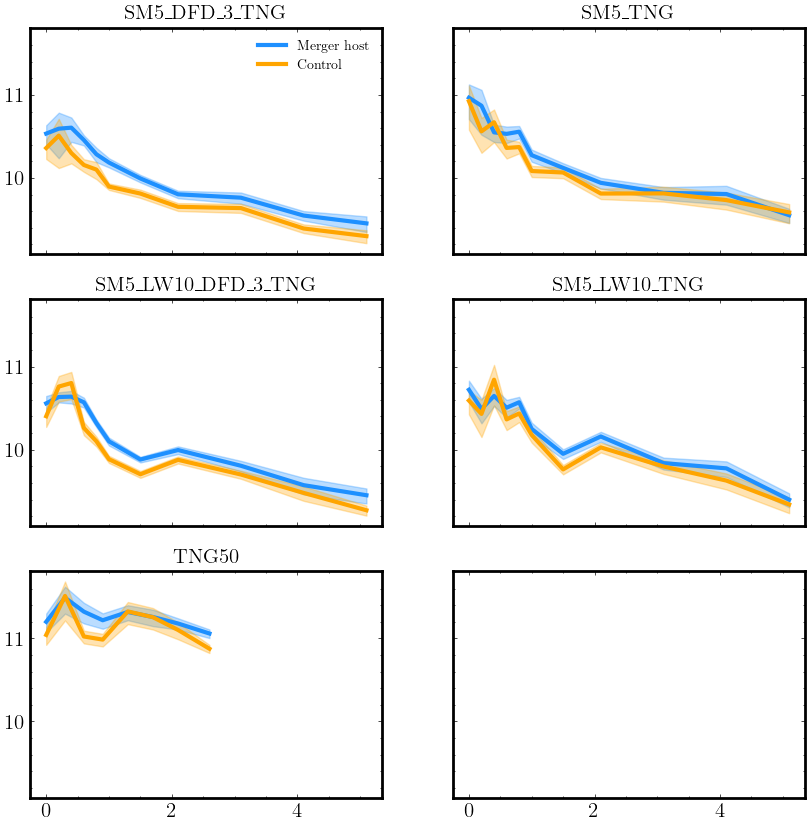

In [22]:
fig, ax = plt.subplots(3,2, figsize=(10, 10), sharex=True,sharey=True)
zbinn = [ 2.002, 3.008, 4.008, 4.996, 6.011]
calculate_quantity_at_z_interval(ax[0,0],sim_objs['SM5_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='Mgas')
calculate_quantity_at_z_interval(ax[0,1],sim_objs['SM5_TNG'],sim_zbins_list['SM5_TNG'],quantity='Mgas')
calculate_quantity_at_z_interval(ax[1,0],sim_objs['SM5_LW10_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='Mgas')
calculate_quantity_at_z_interval(ax[1,1],sim_objs['SM5_LW10_TNG'],sim_zbins_list['SM5_TNG'],quantity='Mgas')
calculate_quantity_at_z_interval(ax[2,0],sim_objs['TNG50'],sim_zbins_list['TNG50'],quantity='Mgas')
# ax[0,0].set_xlim(2,)
# ax[0,1].set_xlim(2,)
ax[0,0].legend()
ax[0,0].set_title('SM5_DFD_3_TNG')
ax[0,1].set_title('SM5_TNG')
ax[1,0].set_title('SM5_LW10_DFD_3_TNG')
ax[1,1].set_title('SM5_LW10_TNG')
ax[2,0].set_title('TNG50')

Text(0.5, 1.0, 'TNG50')

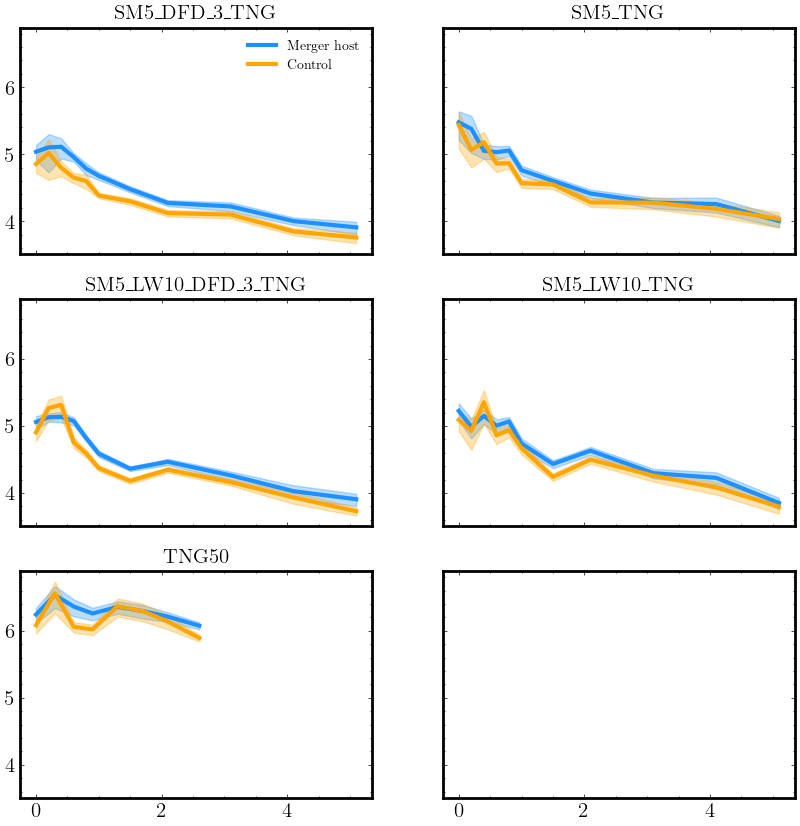

In [23]:
fig, ax = plt.subplots(3,2, figsize=(10, 10), sharex=True,sharey=True)
zbinn = [ 2.002, 3.008, 4.008, 4.996, 6.011]
calculate_quantity_at_z_interval(ax[0,0],sim_objs['SM5_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='Ngas')
calculate_quantity_at_z_interval(ax[0,1],sim_objs['SM5_TNG'],sim_zbins_list['SM5_TNG'],quantity='Ngas')
calculate_quantity_at_z_interval(ax[1,0],sim_objs['SM5_LW10_DFD_3_TNG'],sim_zbins_list['SM5_DFD_3_TNG'],quantity='Ngas')
calculate_quantity_at_z_interval(ax[1,1],sim_objs['SM5_LW10_TNG'],sim_zbins_list['SM5_TNG'],quantity='Ngas')
calculate_quantity_at_z_interval(ax[2,0],sim_objs['TNG50'],sim_zbins_list['TNG50'],quantity='Ngas')
# ax[0,0].set_xlim(2,)
# ax[0,1].set_xlim(2,)
ax[0,0].legend()
ax[0,0].set_title('SM5_DFD_3_TNG')
ax[0,1].set_title('SM5_TNG')
ax[1,0].set_title('SM5_LW10_DFD_3_TNG')
ax[1,1].set_title('SM5_LW10_TNG')
ax[2,0].set_title('TNG50')

In [24]:
# python
for sim in sim_names:
    obj = sim_objs[sim]
    m_z, m_cnt = np.unique(obj.z_merging_pop, return_counts=True)
    c_z, c_cnt = np.unique(obj.z_control_pop, return_counts=True)
    c_map = dict(zip(c_z, c_cnt))

    print(f"\n{sim}: mergers_total={m_cnt.sum()}, controls_total={c_cnt.sum()}")
    for z,mc in zip(m_z, m_cnt):
        print(f" z={z:.3f}: mergers={mc}, controls={c_map.get(z,0)}")


SM5_TNG: mergers_total=664, controls_total=664
 z=0.000: mergers=7, controls=8
 z=0.099: mergers=8, controls=10
 z=0.197: mergers=7, controls=4
 z=0.298: mergers=10, controls=10
 z=0.400: mergers=10, controls=11
 z=0.503: mergers=37, controls=37
 z=0.700: mergers=53, controls=55
 z=0.997: mergers=95, controls=92
 z=1.496: mergers=97, controls=97
 z=2.002: mergers=138, controls=138
 z=3.008: mergers=97, controls=97
 z=4.008: mergers=48, controls=48
 z=4.996: mergers=33, controls=33
 z=6.011: mergers=17, controls=17
 z=7.005: mergers=4, controls=4
 z=8.012: mergers=3, controls=3

SM5_LW10_TNG: mergers_total=539, controls_total=539
 z=0.000: mergers=5, controls=5
 z=0.099: mergers=8, controls=7
 z=0.197: mergers=5, controls=6
 z=0.298: mergers=6, controls=6
 z=0.400: mergers=8, controls=8
 z=0.503: mergers=25, controls=27
 z=0.700: mergers=51, controls=57
 z=0.997: mergers=72, controls=64
 z=1.496: mergers=69, controls=69
 z=2.002: mergers=96, controls=96
 z=3.008: mergers=88, controls=8